In [5]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from helpful_functions import *
# import pandas
# from tqdm import tqdm

In [2]:
drive_parameters = {
    'N_q': 6,   
    'N_c': 12,
    'detuning': 165*2*np.pi,  # qubit-resonator detuning in angular frequency
    'gbs': 1.0*2*np.pi,       # qubit-resonator coupling strength in angular frequency
}
alpha = -160.0*2*np.pi  # qubit anharmonicity in MHz angular frequency
results = dchi_H(drive_parameters, alpha)
print(f'Dispersive shift chi list: {np.array(results['chi_dict']['chi_list'])/(2*np.pi)} MHz')

Dispersive shift chi list: [-0.36092235 -0.31612066 -0.2841849  -0.25992822 -0.24069082 -0.22494786
 -0.21175365 -0.20048623 -0.19071741 -0.18214149 -0.22932023] MHz


In [47]:
0.05/0.36
1/165

0.006060606060606061

In [3]:
a_r_dressed = results['dressed_operators']['a_r']
a_q_dressed = results['dressed_operators']['a_q']
w_r_dressed = results['dressed_operators']['w_r_dressed']
w_q_dressed = results['dressed_operators']['w_q_dressed']
chi = results['chi_dict']['chi_list'][0]  # dispersive shift for 0->1 transition

H0_approx = w_r_dressed * a_r_dressed.dag() * a_r_dressed + w_q_dressed * a_q_dressed.dag() * a_q_dressed + chi * a_r_dressed.dag() * a_r_dressed * a_q_dressed.dag() * a_q_dressed
H0_exact = results['Hamiltonian_dict']['H0']

evals_approx, evecs_approx = H0_approx.eigenstates()
sorted_dict_approx = sort_eigenvalues_eigenstates_by_excitation_number(evals_approx, evecs_approx, drive_parameters['N_c'], drive_parameters['N_q'], results['Hamiltonian_dict']['a_r'], results['Hamiltonian_dict']['a_q'])
# sorted_dict_approx = sort_eigenvalues_eigenstates_by_excitation_number(evals_approx, evecs_approx, drive_parameters['N_c'], drive_parameters['N_q'], a_r_dressed, a_q_dressed)

evals_sorted_approx = sorted_dict_approx['evals_sorted']
evals_sorted_exact = results['sorted_dict']['evals_sorted']
evecs_sorted_approx = sorted_dict_approx['evecs_sorted']
evecs_sorted_exact = results['sorted_dict']['evecs_sorted']

Nr_subspace_dim = 2
Nq_subspace_dim = 2

Projector = projector_onto_states([results['sorted_dict']['evecs_sorted'][n_r][n_q] for n_r in range(Nr_subspace_dim) for n_q in range(Nq_subspace_dim)])

H0_approx_nodressed = w_r_dressed * results['Hamiltonian_dict']['a_r'].dag() * results['Hamiltonian_dict']['a_r'] + w_q_dressed * results['Hamiltonian_dict']['a_q'].dag() * results['Hamiltonian_dict']['a_q'] + chi * results['Hamiltonian_dict']['a_r'].dag() * results['Hamiltonian_dict']['a_r'] * results['Hamiltonian_dict']['a_q'].dag() * results['Hamiltonian_dict']['a_q'] # if we don't use dressed operators. this is close but defintely not exact. Exact is with dressed operators.

# H0_approx = w_q_dressed * a_q_dressed.dag() * a_q_dressed + chi * a_r_dressed.dag() * a_r_dressed * a_q_dressed.dag() * a_q_dressed, without resonator term. this term is important for exactness but is small. in the 2 by 2 subspace we get smaller inner product error without it.

print(evecs_sorted_exact[0][1].dag()*evecs_sorted_approx[0][1])
# print(sorted_dict_approx['overrides'])
#print(results['sorted_dict']['overrides'])
# print(Projector.tr())
print(normalized_innerproduct_projected(H0_approx,H0_exact,Projector))
print(normalized_innerproduct_projected(H0_approx_nodressed,H0_exact,Projector))


(0.9999999999999996+0j)
(1+0j)
(0.9854307214814214+0j)


In [4]:
evals_qobj = results['sorted_dict']['evals_qobj']
evecs_qobj = results['sorted_dict']['evecs_qobj']

print(norm(evecs_qobj.dag()*H0_exact*evecs_qobj - evals_qobj)) # should be zero to show they are the same

4.195409272896477e-11


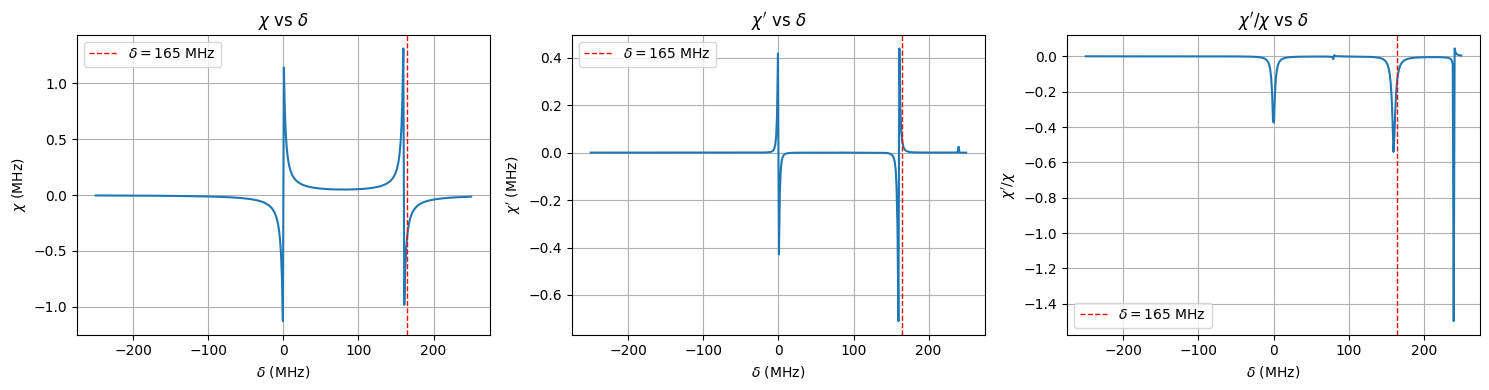

In [74]:
# Sweep delta with fixed g and alpha
gbs_fixed = 1.0 * 2 * np.pi       # g = 1 MHz in angular units
alpha_fixed = -160.0 * 2 * np.pi  # alpha = -160 MHz in angular units

delta_MHz_vals = np.linspace(-250, 250, 400)  # delta in MHz
delta_vals = delta_MHz_vals * 2 * np.pi      # convert to angular units for Hamiltonian

chis = []
chi_primes = []

drive_parameters_sweep = {
    'N_q': 6,
    'N_c': 12,
    'detuning': 1.0,
    'gbs': gbs_fixed,
}

for delta in delta_vals:
    drive_parameters_sweep['detuning'] = delta
    res = dchi_H(drive_parameters_sweep, alpha_fixed)
    chi_list = res['chi_dict']['chi_list']
    chi0 = chi_list[0]
    chi1 = chi_list[1]
    chis.append(chi0/(2*np.pi))  # convert chi to MHz for plotting
    chi_primes.append((chi1 - chi0)/(2*np.pi))  # chi' is the difference between the second and first chi values

chis = np.array(chis)
chi_primes = np.array(chi_primes)

delta_phys_MHz = 165  # physical operating point in MHz

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(delta_MHz_vals, chis)
axes[0].axvline(delta_phys_MHz, color='r', linestyle='--', linewidth=1, label=r'$\delta=165$ MHz')
axes[0].set_xlabel(r'$\delta$ (MHz)')
axes[0].set_ylabel(r'$\chi$ (MHz)')
axes[0].set_title(r'$\chi$ vs $\delta$')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(delta_MHz_vals, chi_primes)
axes[1].axvline(delta_phys_MHz, color='r', linestyle='--', linewidth=1, label=r'$\delta=165$ MHz')
axes[1].set_xlabel(r'$\delta$ (MHz)')
axes[1].set_ylabel(r"$\chi'$ (MHz)")
axes[1].set_title(r"$\chi'$ vs $\delta$")
axes[1].legend(); axes[1].grid(True)

ratio = chi_primes / chis
axes[2].plot(delta_MHz_vals, ratio)
axes[2].axvline(delta_phys_MHz, color='r', linestyle='--', linewidth=1, label=r'$\delta=165$ MHz')
axes[2].set_xlabel(r'$\delta$ (MHz)')
axes[2].set_ylabel(r"$\chi'/\chi$")
axes[2].set_title(r"$\chi'/\chi$ vs $\delta$")
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()


In [71]:
chis[250]

np.float64(0.05224565796681159)

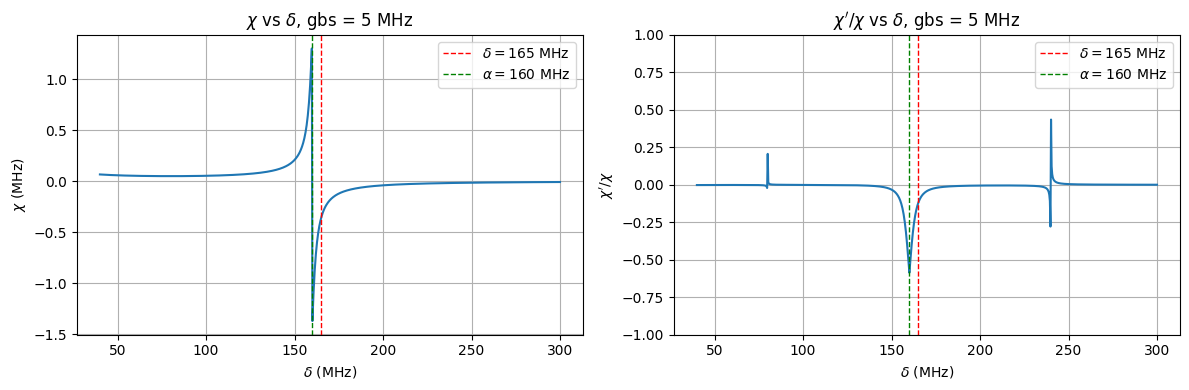

In [97]:
# Zoomed in: chi and chi'/chi vs delta (MHz), linear spacing
delta_MHz_zoom = np.linspace(40, 300, 800)
delta_zoom = delta_MHz_zoom * 2 * np.pi

gbs_fixed = 1.0 * 2 * np.pi       # g = 2 MHz in angular units
alpha_fixed = -160.0 * 2 * np.pi  # alpha = -160 MHz in angular units

drive_parameters_sweep = {
    'N_q': 6,
    'N_c': 12,
    'detuning': 1.0,
    'gbs': gbs_fixed,
}

delta_MHz_plot = []
chi_zoom = []
chi_prime_over_chi_zoom = []

for i, delta in enumerate(delta_zoom):
    drive_parameters_sweep['detuning'] = delta
    res = dchi_H(drive_parameters_sweep, alpha_fixed)
    chi_list = res['chi_dict']['chi_list']
    if len(chi_list) < 2:
        continue
    chi0 = chi_list[0]
    chi1 = chi_list[1]
    delta_MHz_plot.append(delta_MHz_zoom[i])
    chi_zoom.append(chi0 / (2 * np.pi))
    chi_prime_over_chi_zoom.append((chi1 - chi0) / chi0)

delta_MHz_plot = np.array(delta_MHz_plot)
chi_zoom = np.array(chi_zoom)
chi_prime_over_chi_zoom = np.array(chi_prime_over_chi_zoom)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(delta_MHz_plot, chi_zoom)
axes[0].axvline(165, color='r', linestyle='--', linewidth=1, label=r'$\delta=165$ MHz')
axes[0].axvline(160, color='g', linestyle='--', linewidth=1, label=r'$\alpha=160$ MHz')
axes[0].set_xlabel(r'$\delta$ (MHz)')
axes[0].set_ylabel(r'$\chi$ (MHz)')
axes[0].set_title(r'$\chi$ vs $\delta$, gbs = 5 MHz')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(delta_MHz_plot, chi_prime_over_chi_zoom)
axes[1].axvline(165, color='r', linestyle='--', linewidth=1, label=r'$\delta=165$ MHz')
axes[1].axvline(160, color='g', linestyle='--', linewidth=1, label=r'$\alpha=160$ MHz')
axes[1].set_xlabel(r'$\delta$ (MHz)')
axes[1].set_ylabel(r"$\chi'/\chi$")
axes[1].set_title(r"$\chi'/\chi$ vs $\delta$, gbs = 5 MHz")
axes[1].set_ylim(-1, 1)
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


In [90]:
chi_zoom[70]

np.float64(0.8532399576549179)